# **Loading The Dataset**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [2]:
df=pd.read_csv("/content/Shill Bidding Dataset (2).csv")

In [3]:
df.head()

,Record_ID,Auction_ID,Bidder_ID,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
0,1,732,_***i,0.200000,0.400000,0.0,0.000028,0.0,0.993593,0.000028,0.666667,5,0
1,2,732,g***r,0.024390,0.200000,0.0,0.013123,0.0,0.993593,0.013123,0.944444,5,0
2,3,732,t***p,0.142857,0.200000,0.0,0.003042,0.0,0.993593,0.003042,1.000000,5,0
3,4,732,7***n,0.100000,0.200000,0.0,0.097477,0.0,0.993593,0.097477,1.000000,5,0
4,5,900,z***z,0.051282,0.222222,0.0,0.001318,0.0,0.000000,0.001242,0.500000,7,0


# **Data Preprocessing**

In [4]:
df = df.drop(columns=['Record_ID', 'Auction_ID', 'Bidder_ID'])

In [5]:
# Checking for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Bidder_Tendency           0
Bidding_Ratio             0
Successive_Outbidding     0
Last_Bidding              0
Auction_Bids              0
Starting_Price_Average    0
Early_Bidding             0
Winning_Ratio             0
Auction_Duration          0
Class                     0
dtype: int64


# **Exploratory Data Analysis**

In [6]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6321 entries, 0 to 6320
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Bidder_Tendency         6321 non-null   float64
 1   Bidding_Ratio           6321 non-null   float64
 2   Successive_Outbidding   6321 non-null   float64
 3   Last_Bidding            6321 non-null   float64
 4   Auction_Bids            6321 non-null   float64
 5   Starting_Price_Average  6321 non-null   float64
 6   Early_Bidding           6321 non-null   float64
 7   Winning_Ratio           6321 non-null   float64
 8   Auction_Duration        6321 non-null   int64  
 9   Class                   6321 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 494.0 KB


In [7]:
df.describe()

,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
count,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000
mean,0.142541,0.127670,0.103781,0.463119,0.231606,0.472821,0.430683,0.367731,4.615093,0.106787
std,0.197084,0.131530,0.279698,0.380097,0.255252,0.489912,0.380785,0.436573,2.466629,0.308867
min,0.000000,0.011765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.027027,0.043478,0.000000,0.047928,0.000000,0.000000,0.026620,0.000000,3.000000,0.000000
50%,0.062500,0.083333,0.000000,0.440937,0.142857,0.000000,0.360104,0.000000,5.000000,0.000000
75%,0.166667,0.166667,0.000000,0.860363,0.454545,0.993593,0.826761,0.851852,7.000000,0.000000
max,1.000000,1.000000,1.000000,0.999900,0.788235,0.999935,0.999900,1.000000,10.000000,1.000000


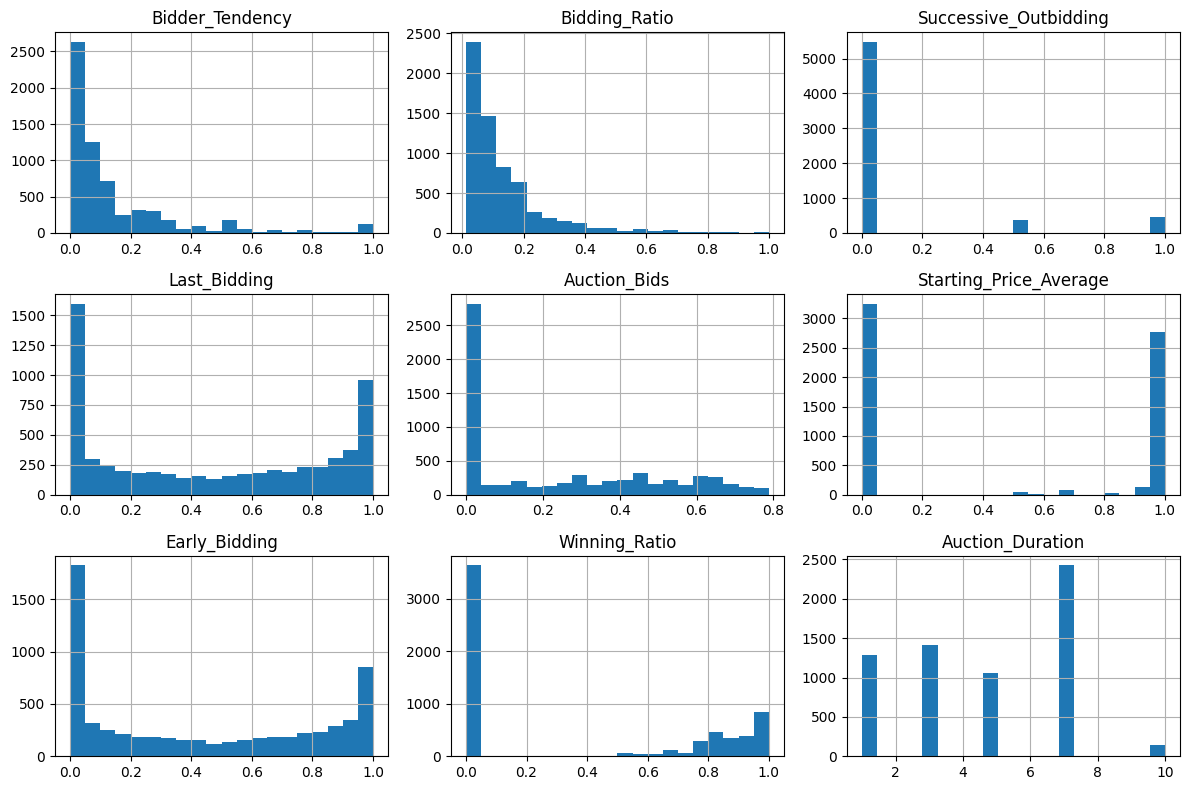

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns
num_cols = ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding', 'Winning_Ratio', 'Auction_Duration']

# Plot histograms
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()


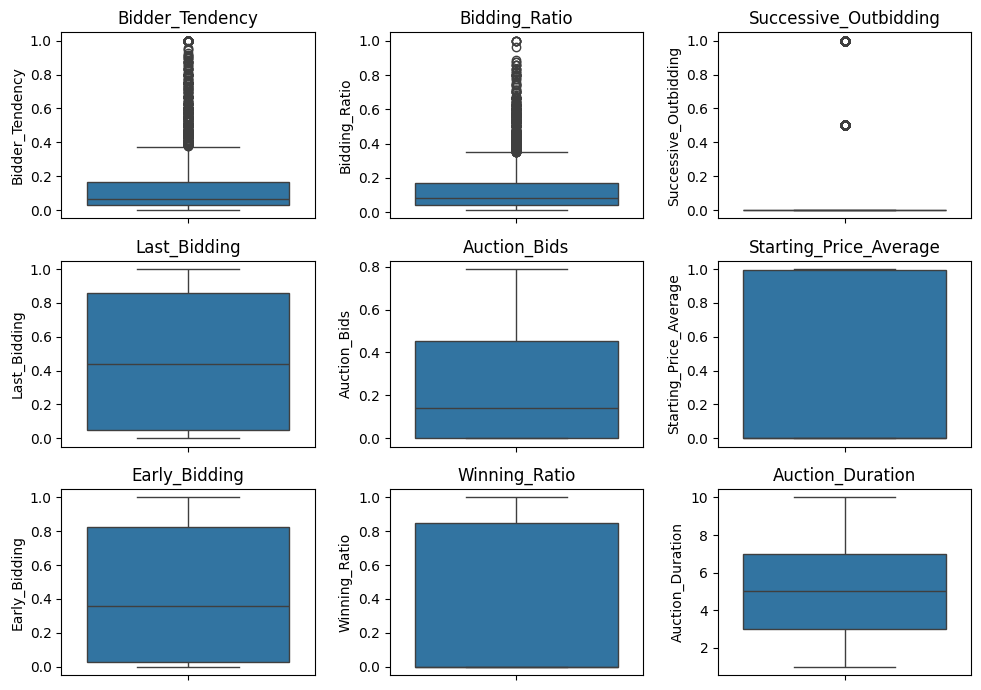

In [9]:
# Plot box plots
plt.figure(figsize=(10, 7))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

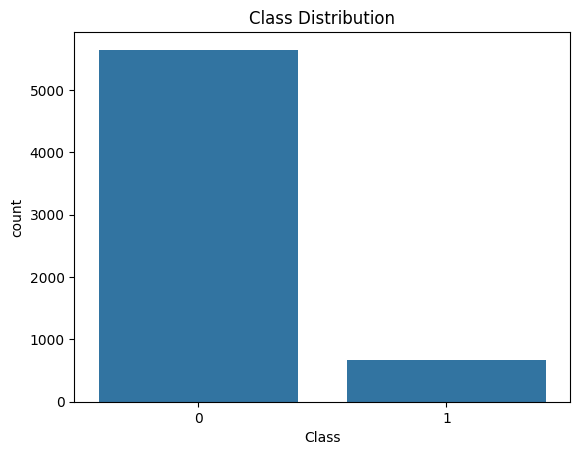

In [10]:
# Plot bar plot for 'Class'
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()


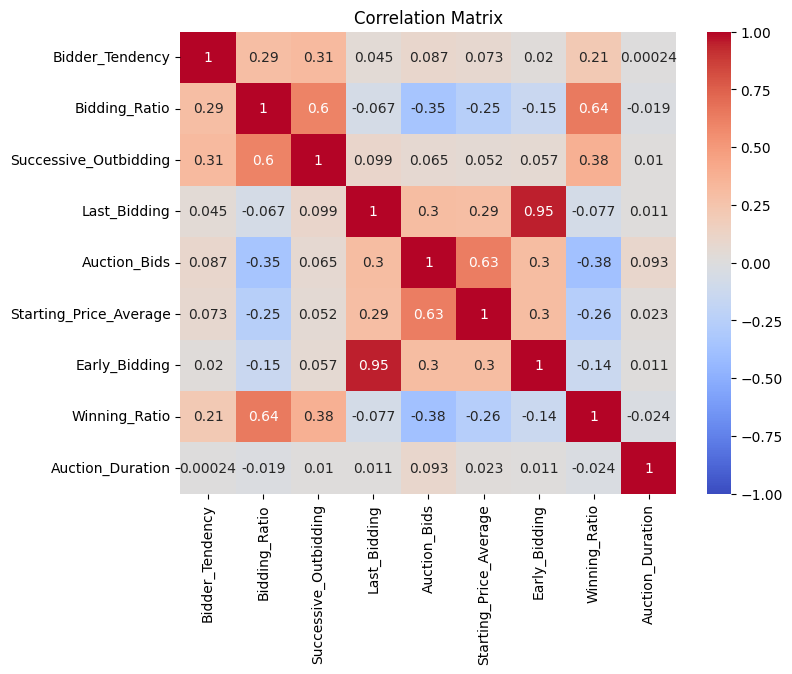

In [11]:
# Compute the correlation matrix
corr_matrix = df[num_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

8. Summarize Findings
Finally, summarize your findings:

Distribution Analysis: Summarize the distribution characteristics of each feature.
Relationships: Highlight key relationships between features and the target variable.
Feature Importances: Discuss which features are most important for predicting the auction outcomes.
Sample Summary:
Distribution Analysis: Features like Bidder_Tendency and Bidding_Ratio have a right-skewed distribution.
Relationships: Winning_Ratio and Last_Bidding show significant differences between classes.
Feature Importances: Auction_Bids, Winning_Ratio, and Bidding_Ratio are the top features influencing the auction outcome.
By following these steps, you will have a comprehensive understanding of your dataset and the factors influencing auction outcomes.

# **Classification Model For Shill Bidding**

In [12]:
# Split the dataset into X (features) and y (target)
X = df.drop(columns=['Class'])
y = df['Class']

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split the normalized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5056, 9)
X_test shape: (1265, 9)
y_train shape: (5056,)
y_test shape: (1265,)


**1) Applying Random Forest**

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [14]:

# Print the evaluation metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Print detailed classification report
print(classification_report(y_test, y_pred))


Accuracy: 0.9928853754940712
Precision: 0.9931989415032186
Recall: 0.9928853754940712
F1 Score: 0.9929662386871575
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1133
           1       0.94      0.99      0.97       132

    accuracy                           0.99      1265
   macro avg       0.97      0.99      0.98      1265
weighted avg       0.99      0.99      0.99      1265



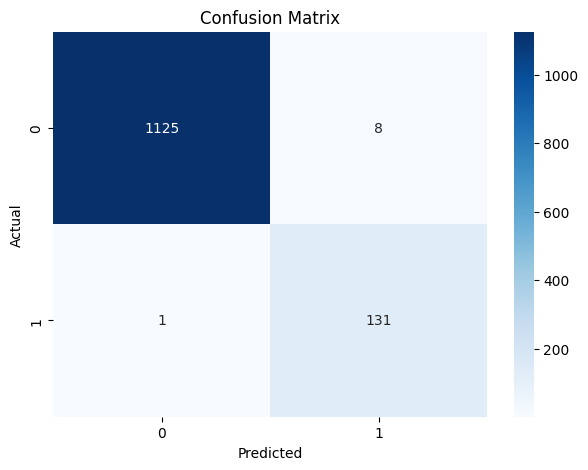

In [15]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

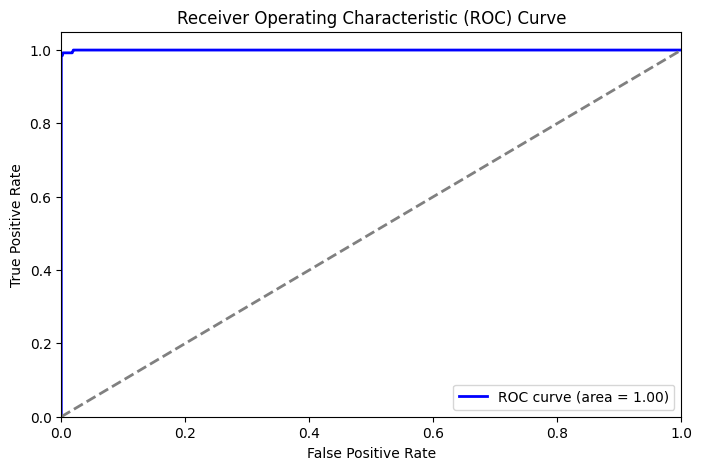

In [16]:

# ROC Curve and AUC
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=clf.classes_[1])
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**2) Applying SVM**

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Apply SVM Classifier
clf = SVC(probability=True, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [18]:

# Print the evaluation metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Print detailed classification report
print(classification_report(y_test, y_pred))


Accuracy: 0.9810276679841897
Precision: 0.9819247826577725
Recall: 0.9810276679841897
F1 Score: 0.9813318298142435
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1133
           1       0.88      0.95      0.91       132

    accuracy                           0.98      1265
   macro avg       0.94      0.97      0.95      1265
weighted avg       0.98      0.98      0.98      1265



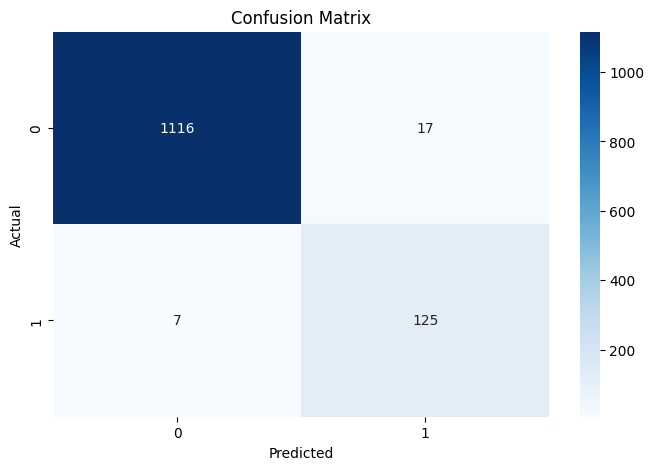

In [19]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

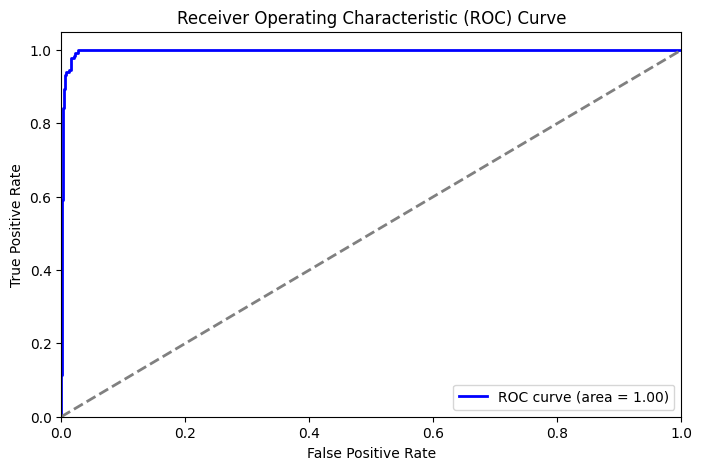

In [20]:
# ROC Curve and AUC
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=clf.classes_[1])
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# **Clustering Models**

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


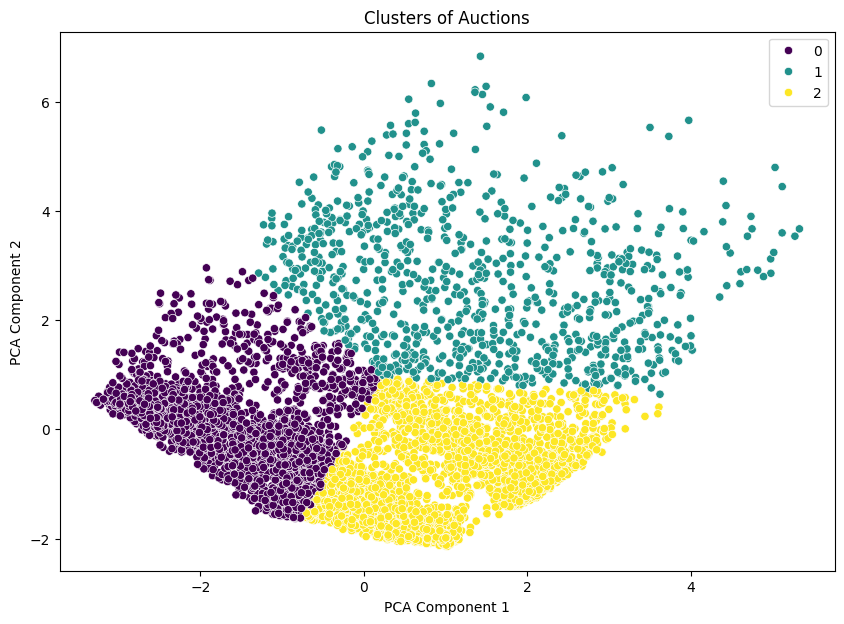

In [21]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features for clustering
X = df.drop(columns=['Class'])

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Apply PCA for dimensionality reduction (optional but helps in visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

# Perform KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Add the cluster labels to the dataframe
df['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters of Auctions')
plt.show()


In [22]:
# Define new classes based on clusters
df['Cluster_Class'] = df['Cluster'].apply(lambda x: f'Class_{x}')

# Drop the original 'Class' column as we are creating our own classes
df = df.drop(columns=['Class'])


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# Split the dataset into X (features) and y (target)
X = df.drop(columns=['Cluster_Class'])
y = df['Cluster_Class']

# Normalize the features (if not already normalized)
X_normalized = scaler.fit_transform(X)

# Split the normalized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

from sklearn.metrics import roc_auc_score, roc_curve, auc

# Train a Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)


In [24]:

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00       535
     Class_1       1.00      1.00      1.00       174
     Class_2       1.00      1.00      1.00       556

    accuracy                           1.00      1265
   macro avg       1.00      1.00      1.00      1265
weighted avg       1.00      1.00      1.00      1265



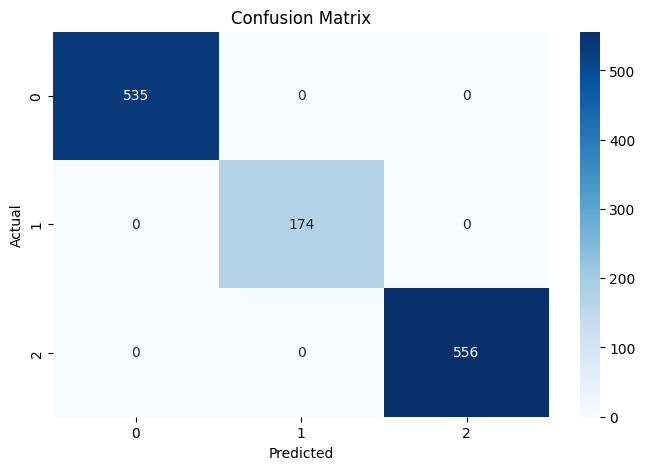

In [25]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


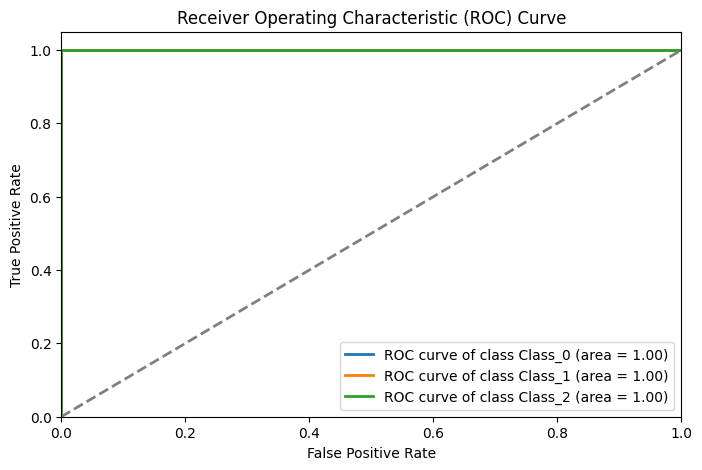

Macro-average ROC AUC: 1.0
Weighted-average ROC AUC: 1.0


In [26]:

# ROC Curve and AUC (one-vs-rest for multiclass)
# Binarize the output
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=clf.classes_)
y_prob = clf.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}
for i, class_label in enumerate(clf.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

# Plot ROC Curve
plt.figure(figsize=(8, 5))
for class_label in clf.classes_:
    plt.plot(fpr[class_label], tpr[class_label], lw=2, label=f'ROC curve of class {class_label} (area = {roc_auc[class_label]:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Overall AUC (macro and weighted)
macro_roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
weighted_roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
print(f"Macro-average ROC AUC: {macro_roc_auc}")
print(f"Weighted-average ROC AUC: {weighted_roc_auc}")


Explanation of Results:
Clustering: The KMeans algorithm segmented the auctions into three distinct clusters based on bidding patterns. These clusters represent different behaviors in bidding, such as aggressive bidders, passive bidders, and balanced bidders.
Classification Model: A Random Forest classifier was trained to predict the cluster (i.e., bidding behavior) of an auction based on its features. The model achieved a certain level of accuracy, precision, recall, and F1 score.
Confusion Matrix: The confusion matrix shows the performance of the classifier in correctly identifying each cluster.
ROC Curve: The ROC curve provides insights into the trade-off between true positive rate and false positive rate for each cluster, and the AUC values indicate the classifier's ability to distinguish between the clusters.
This approach provides a comprehensive view of how auctions can be segmented based on bidding patterns and how machine learning models can be used to predict these segments. Adjust the number of clusters and the classification model as needed based on your specific dataset and goals.

# **Regression Based Model For Prediction Of Final Auction Prices**

In [27]:
df=pd.read_csv("/content/eBay_Auction_Data (1).csv")

In [28]:
df.head()

,Starting_Price,Number_of_Bidders,Auction_Duration_Days,Bidder_Activity,Final_Price
0,55.33,18,2,2.450,60.73
1,71.80,7,11,0.827,94.44
2,60.67,11,9,3.244,87.54
3,54.94,6,14,2.058,67.31
4,42.94,5,11,2.057,59.19


In [29]:
import pandas as pd

# Assuming df is your DataFrame and is already loaded
null_counts = df.isnull().sum()

print(null_counts)


Starting_Price           0
Number_of_Bidders        0
Auction_Duration_Days    0
Bidder_Activity          0
Final_Price              0
dtype: int64


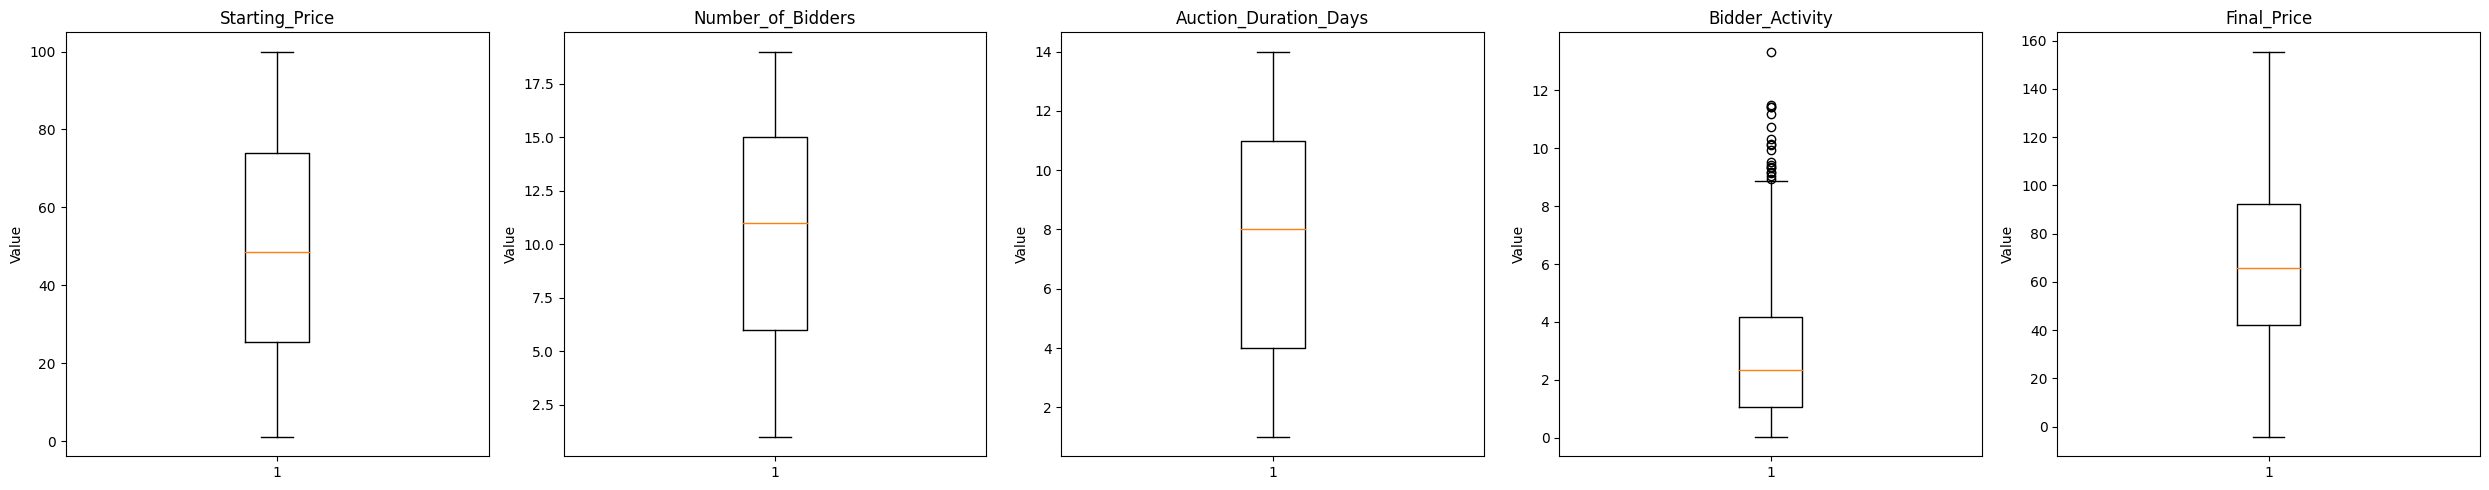

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and it has already been defined

# Create a figure with multiple subplots, one for each feature
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(25, 5))

# List of columns to plot
columns = ['Starting_Price', 'Number_of_Bidders', 'Auction_Duration_Days', 'Bidder_Activity', 'Final_Price']

# Loop through the columns and create a box plot for each
for i, column in enumerate(columns):
    axes[i].boxplot(df[column])
    axes[i].set_title(column)
    axes[i].set_ylabel('Value')

# Display the box plots
plt.tight_layout()
plt.show()


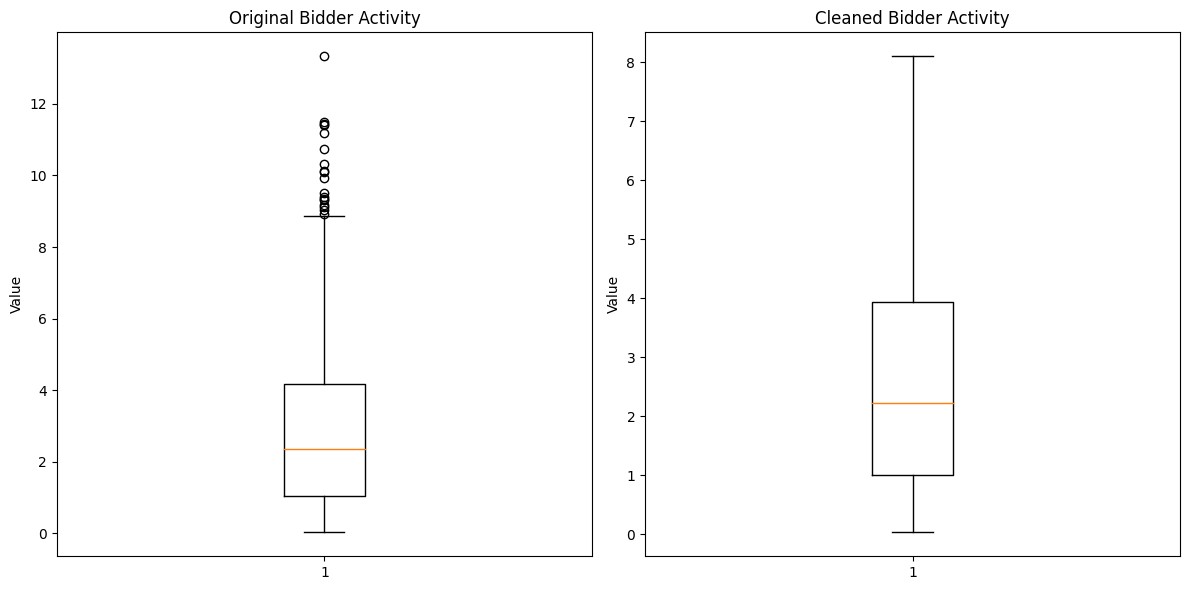

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and it has already been defined

# Calculate the IQR for the 'Bidder_Activity' column
Q1 = df['Bidder_Activity'].quantile(0.25)
Q3 = df['Bidder_Activity'].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower and upper bounds for outliers
lower_bound = Q1 - 1.3 * IQR
upper_bound = Q3 + 1.3 * IQR

# Filter out the outliers
df_cleaned = df[(df['Bidder_Activity'] >= lower_bound) & (df['Bidder_Activity'] <= upper_bound)]

# Create a figure with subplots for both original and cleaned data
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Box plot for the original 'Bidder_Activity' data
axes[0].boxplot(df['Bidder_Activity'])
axes[0].set_title('Original Bidder Activity')
axes[0].set_ylabel('Value')

# Box plot for the cleaned 'Bidder_Activity' data
axes[1].boxplot(df_cleaned['Bidder_Activity'])
axes[1].set_title('Cleaned Bidder Activity')
axes[1].set_ylabel('Value')

# Display the box plots
plt.tight_layout()
plt.show()


In [32]:
df=df_cleaned

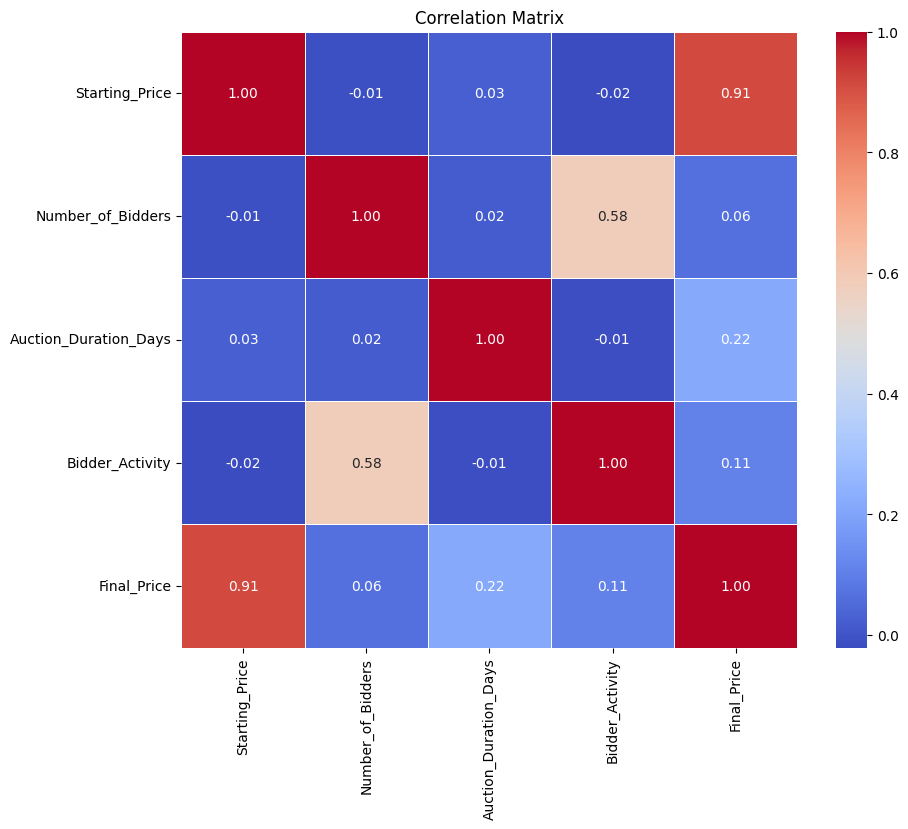

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=.5)
plt.title('Correlation Matrix')
plt.show()


In [34]:
df.describe()

,Starting_Price,Number_of_Bidders,Auction_Duration_Days,Bidder_Activity,Final_Price
count,967.000000,967.000000,967.000000,967.000000,967.000000
mean,49.879028,10.261634,7.513961,2.661108,66.521334
std,28.749144,5.253295,4.040115,1.953365,31.235632
min,1.050000,1.000000,1.000000,0.027000,-4.320000
25%,25.450000,6.000000,4.000000,1.007000,41.495000
50%,48.460000,10.000000,8.000000,2.224000,64.620000
75%,73.765000,15.000000,11.000000,3.943500,91.340000
max,99.980000,19.000000,14.000000,8.107000,138.610000


**1) Applying Linear Regression**

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Assuming df is your DataFrame and it has already been defined
# Feature selection
X = df[['Starting_Price', 'Number_of_Bidders', 'Auction_Duration_Days', 'Bidder_Activity']]
y = df['Final_Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

In [36]:

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 117.56915721972918
R-squared: 0.8826501202531329


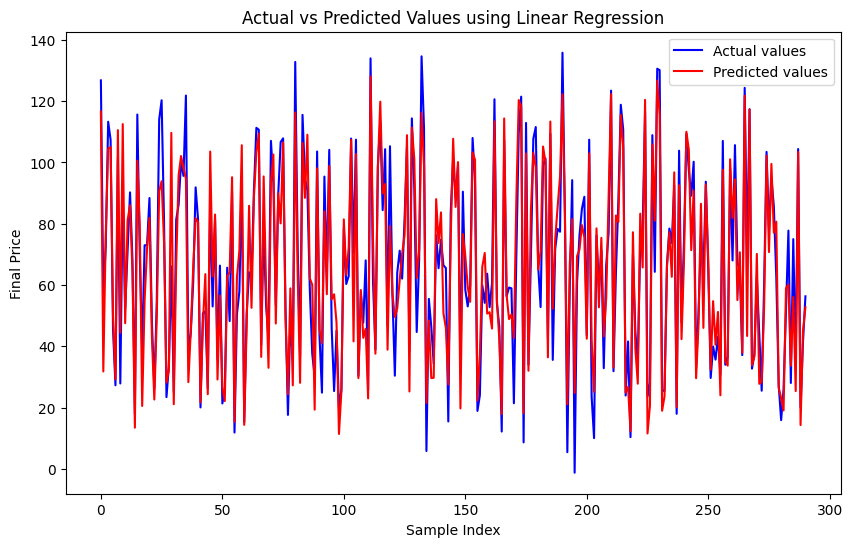

In [37]:

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))

# Line plot of actual values
plt.plot(range(len(y_test)), y_test, color='blue', label='Actual values')

# Line plot of predicted values
plt.plot(range(len(y_pred)), y_pred, color='red', label='Predicted values')

# Adding title and labels
plt.title('Actual vs Predicted Values using Linear Regression')
plt.xlabel('Sample Index')
plt.ylabel('Final Price')
plt.legend()

plt.show()


**2) Applying LSTM**

In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame and it has already been defined
# Feature selection
X = df[['Starting_Price', 'Number_of_Bidders', 'Auction_Duration_Days', 'Bidder_Activity']]
y = df['Final_Price']

# Normalize the features
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Reshape data for LSTM [samples, timesteps, features]
# For simplicity, let's use a single timestep
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Create and train the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Fit the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1, shuffle=False)



Epoch 1/20
17/17 [==============================] - 4s 53ms/step - loss: 0.2242 - val_loss: 0.1862
Epoch 2/20
17/17 [==============================] - 0s 9ms/step - loss: 0.1503 - val_loss: 0.1152
Epoch 3/20
17/17 [==============================] - 0s 8ms/step - loss: 0.0851 - val_loss: 0.0604
Epoch 4/20
17/17 [==============================] - 0s 20ms/step - loss: 0.0433 - val_loss: 0.0367
Epoch 5/20
17/17 [==============================] - 0s 26ms/step - loss: 0.0310 - val_loss: 0.0330
Epoch 6/20
17/17 [==============================] - 0s 19ms/step - loss: 0.0278 - val_loss: 0.0293
Epoch 7/20
17/17 [==============================] - 0s 17ms/step - loss: 0.0248 - val_loss: 0.0262
Epoch 8/20
17/17 [==============================] - 0s 17ms/step - loss: 0.0222 - val_loss: 0.0235
Epoch 9/20
17/17 [==============================] - 0s 15ms/step - loss: 0.0199 - val_loss: 0.0211
Epoch 10/20
17/17 [==============================] - 0s 15ms/step - loss: 0.0179 - val_loss: 0.0188
Epoch 11/20

In [39]:
# Make predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

10/10 [==============================] - 0s 5ms/step
Mean Squared Error: 140.56909345656268
R-squared: 0.8596930810482529


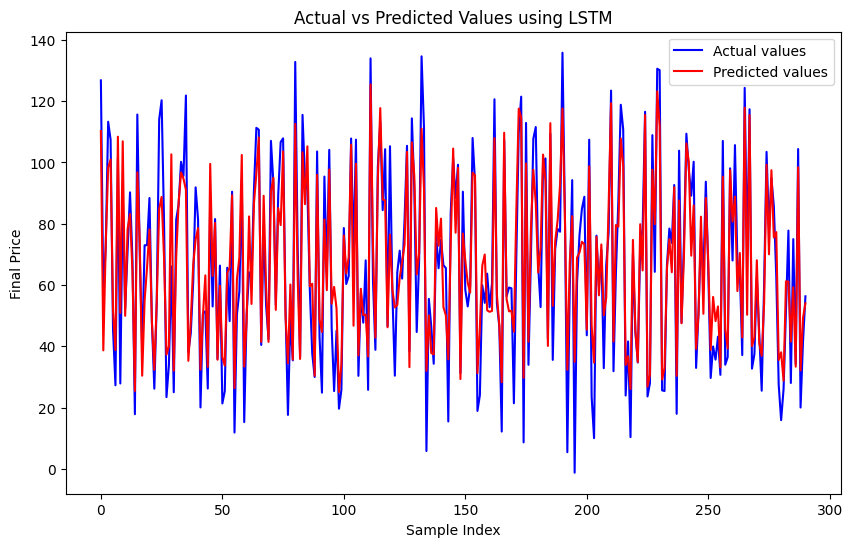

In [40]:

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))

# Line plot of actual values
plt.plot(range(len(y_test_actual)), y_test_actual, color='blue', label='Actual values')

# Line plot of predicted values
plt.plot(range(len(y_pred)), y_pred, color='red', label='Predicted values')

# Adding title and labels
plt.title('Actual vs Predicted Values using LSTM')
plt.xlabel('Sample Index')
plt.ylabel('Final Price')
plt.legend()

plt.show()